In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model

In [2]:
gold = yf.download("GC=F", start="2000-01-01", end="2024-12-31")
gold = gold[['Close']]
gold.dropna(inplace=True)
#gold.to_csv("Data/gold_prices_raw.csv")

C:\Users\princ\AppData\Local\Temp\ipykernel_18764\1697174765.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F", start="2000-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [3]:
gold.head()
gold.describe()
gold.count()
gold

Price,Close
Ticker,GC=F
Date,
2000-08-30,273.899994
2000-08-31,278.299988
2000-09-01,277.000000
2000-09-05,275.799988
2000-09-06,274.200012
...,...
2024-12-23,2612.300049
2024-12-24,2620.000000


In [4]:
gold = gold.asfreq('B')  # Business day frequency
gold['Close'] = gold['Close'].ffill()

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

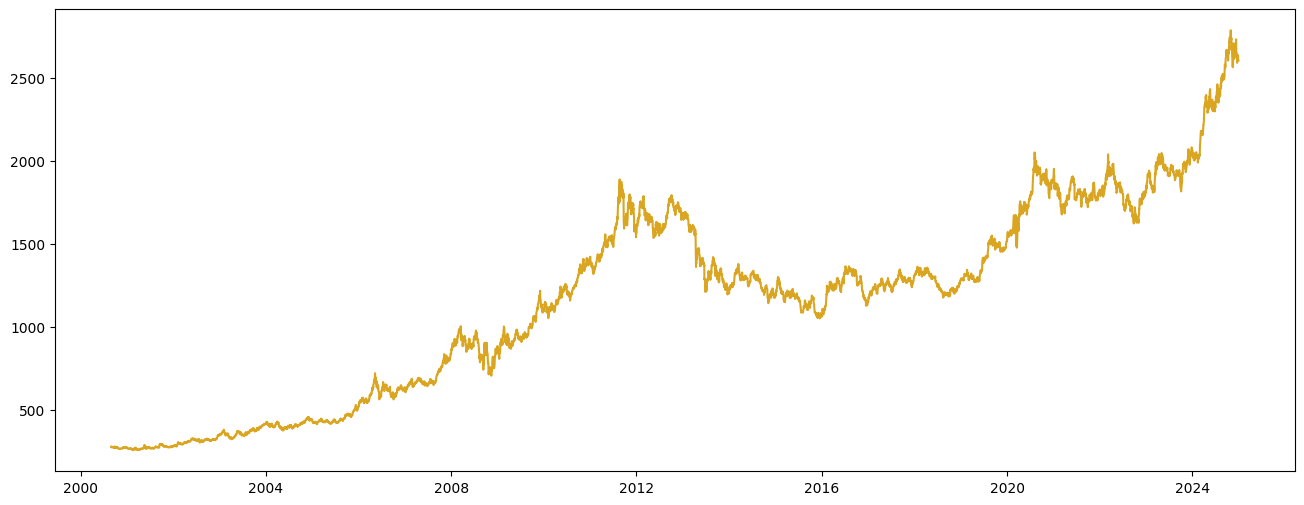

In [7]:
# Key events to annotate
events = {
    '2008-09-15': '2008\nFinancial Crisis',
    '2011-09-06': '2011\nATH',
    '2020-08-07': 'COVID-19\nATH',
    '2022-03-08': '2022\nUkraine War'
}

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(gold.index, gold['Close'], color='goldenrod', linewidth=1.5, label='Gold Price (USD)')
ax.fill_between(gold.index, gold['Close'].to_numpy, alpha=0.1, color='goldenrod')

# Add event annotations
for date, label in events.items():
    price = gold.loc[gold.index >= date, 'Close'].iloc[0]
    ax.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.6, linewidth=1)
    ax.annotate(label, xy=(pd.Timestamp(date), price),
                xytext=(10, 20), textcoords='offset points',
                fontsize=9, color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=1))

ax.set_title('Gold Futures Price (USD) — 2000 to 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Price (USD per Troy Ounce)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()

plt.tight_layout()
plt.savefig('graph1_gold_price.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
gold

Price,Close
Ticker,GC=F
Date,
2000-08-30,273.899994
2000-08-31,278.299988
2000-09-01,277.000000
2000-09-04,277.000000
2000-09-05,275.799988
...,...
2024-12-24,2620.000000
2024-12-25,2620.000000


In [10]:
z_scores = (gold['Close'] - gold['Close'].mean()) / gold['Close'].std()
outliers = gold[z_scores.abs() > 5]
print(outliers)

Price      Close
Ticker      GC=F
Date            
2000-08-30   NaN
2000-08-31   NaN
2000-09-01   NaN
2000-09-04   NaN
2000-09-05   NaN
...          ...
2024-12-24   NaN
2024-12-25   NaN
2024-12-26   NaN
2024-12-27   NaN
2024-12-30   NaN

[6349 rows x 1 columns]


In [11]:
gold['Log_Return'] = np.log(gold['Close'] / gold['Close'].shift(1))
gold.dropna(inplace=True)

In [12]:
#gold.to_csv("Data/gold_prices_clean.csv")

In [14]:
gold

Price,Close,Log_Return
Ticker,GC=F,
Date,,
2000-08-31,278.299988,0.015937
2000-09-01,277.000000,-0.004682
2000-09-04,277.000000,0.000000
2000-09-05,275.799988,-0.004342
2000-09-06,274.200012,-0.005818
...,...,...
2024-12-24,2620.000000,0.002943
2024-12-25,2620.000000,0.000000


In [15]:
print(gold['Log_Return'].describe())
print(f"Skewness: {gold['Log_Return'].skew():.4f}")
print(f"Kurtosis: {gold['Log_Return'].kurt():.4f}")

count    6348.000000
mean        0.000355
std         0.010664
min        -0.098206
25%        -0.004458
50%         0.000132
75%         0.005908
max         0.086432
Name: Log_Return, dtype: float64
Skewness: -0.2977
Kurtosis: 5.6890


In [16]:
gold['Vol_30d'] = gold['Log_Return'].rolling(window=30).std() * np.sqrt(252)
gold['Vol_90d'] = gold['Log_Return'].rolling(window=90).std() * np.sqrt(252)

In [17]:
gold

Price,Close,Log_Return,Vol_30d,Vol_90d
Ticker,GC=F,,,
Date,,,,
2000-08-31,278.299988,0.015937,NaN,NaN
2000-09-01,277.000000,-0.004682,NaN,NaN
2000-09-04,277.000000,0.000000,NaN,NaN
2000-09-05,275.799988,-0.004342,NaN,NaN
2000-09-06,274.200012,-0.005818,NaN,NaN
...,...,...,...,...
2024-12-24,2620.000000,0.002943,0.179528,0.154838
2024-12-25,2620.000000,0.000000,0.178056,0.154816


In [18]:
#pip install statsmodels

In [19]:
from scipy import stats
jb_stat, jb_p = stats.jarque_bera(gold['Log_Return'].dropna())
print(f"Jarque-Bera: stat={jb_stat:.4f}, p={jb_p:.4f}")

Jarque-Bera: stat=8637.9177, p=0.0000


In [20]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(gold['Log_Return'].dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}")

ADF Statistic: -25.4790, p-value: 0.0000


In [21]:
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_result = acorr_ljungbox(gold['Log_Return'].dropna()**2, lags=[10, 20], return_df=True)
print(lb_result)

       lb_stat      lb_pvalue
10  551.275391  4.781215e-112
20  979.182031  1.071772e-194


In [22]:
pip install arch

   ---------------------------------------- 0.0/930.4 kB ? eta -:--:--
   ---------------------------------------- 930.4/930.4 kB 7.1 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [23]:
from arch import arch_model

model = arch_model(
    gold['Log_Return'].dropna() * 100,  # Scaled for numerical stability
    vol='Garch',
    p=1,
    q=1,
    dist='normal'
)
result = model.fit(disp='off')
print(result.summary())

# Extract and plot conditional volatility
gold['GARCH_Vol'] = result.conditional_volatility

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8965.79
Distribution:                  Normal   AIC:                           17939.6
Method:            Maximum Likelihood   BIC:                           17966.6
                                        No. Observations:                 6348
Date:                Mon, Apr 20 2026   Df Residuals:                     6347
Time:                        14:17:44   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0304  1.223e-02      2.482  1.306e-02 [6.

In [24]:
gold

Price,Close,Log_Return,Vol_30d,Vol_90d,GARCH_Vol
Ticker,GC=F,,,,
Date,,,,,
2000-08-31,278.299988,0.015937,NaN,NaN,0.678119
2000-09-01,277.000000,-0.004682,NaN,NaN,0.729880
2000-09-04,277.000000,0.000000,NaN,NaN,0.727459
2000-09-05,275.799988,-0.004342,NaN,NaN,0.719416
2000-09-06,274.200012,-0.005818,NaN,NaN,0.716657
...,...,...,...,...,...
2024-12-24,2620.000000,0.002943,0.179528,0.154838,1.091866
2024-12-25,2620.000000,0.000000,0.178056,0.154816,1.074222
